In [2]:
from ssod.apis.inference import init_detector, inference_detector, save_result
import matplotlib.pyplot as plt
import mmcv
import numpy as np
import scipy.io as sio
import os
import scipy
from scipy.optimize import linear_sum_assignment
import re
import pandas as pd
import cv2
import json

In [3]:
parent_path = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/MDA2_dataset_rois/"

images_folder = os.path.join(parent_path,"tiles")

img_list = os.listdir(images_folder)
output_folder = os.path.join(parent_path,"predictions")


In [4]:
checkpoint_folder = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output_batch2_initialWeights"

log_file = os.path.join(checkpoint_folder,"20240920_232642.log.json")

with open(log_file, 'r') as f:
    # Load the JSON data into a list of dictionaries
    log_data = [json.loads(line) for line in f]

log_data = log_data[1:]
log_df = pd.DataFrame(log_data)
val_df = log_df[log_df['mode'] == 'val']
min_loss_row = val_df.loc[val_df['loss'].idxmin()]
best_epoch = int(min_loss_row['epoch'])
best_checkpoint_path = os.path.join(checkpoint_folder, "epoch_{}.pth".format(best_epoch))
best_checkpoint_path

'/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output_batch2_initialWeights/epoch_98.pth'

In [5]:
config_file = os.path.join(checkpoint_folder,"ACFormer_Lizard_finetune_batch2_inference.py")

num_classes = 6
model = init_detector( config = config_file,
                        checkpoint = best_checkpoint_path)


model.inference_on = "globals"
thr = 0.5


/App/ACFormer/ssod/models/global_local_stn_sequence_plus.py:71: UserWarning: nn.init.uniform is now deprecated in favor of nn.init.uniform_.
  torch.nn.init.uniform(m.weight, a=-0.1, b=0.1)


load checkpoint from local path: /rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output_batch2_initialWeights/epoch_98.pth


In [10]:

def print_progress_bar(iteration, total, prefix='', suffix='', decimals=1, length=100, fill='█', print_end="\r"):
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filled_length = int(length * iteration // total)
    bar = fill * filled_length + '-' * (length - filled_length)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=print_end)
    if iteration == total:
        print()

# Function to process a batch of tiles
def process_batch(batch_tile_paths, img_output, model, thr, num_classes):
    batch_results = inference_detector(model, batch_tile_paths)  # Assume inference_detector can handle batches
    for idx, tile_path in enumerate(batch_tile_paths):
        tile_result = batch_results[idx]  # Get the result for the specific tile
        pred_centroid = []
        pred_inst_type = []

        for i in range(num_classes):
            classes = tile_result[i][np.where(tile_result[i][:, 2] > thr)]
            classes = classes[:, :2]
            pred_centroid.extend(classes)
            pred_type = np.full((classes.shape[0], 1), i + 1)
            pred_inst_type.extend(pred_type)

        tile_export_path = os.path.join(img_output, os.path.basename(tile_path) + '.csv')
        tile_data = np.hstack((pred_centroid, pred_inst_type))
        tile_data = tile_data.astype(int)
        np.savetxt(tile_export_path, tile_data, delimiter=",", fmt='%d')

# Main processing function with batching
def process_images(img_list, model, output_folder, images_folder, thr, num_classes, batch_size=256, tile_ext = 'png'):
    for idx, img in enumerate(img_list):
        # print("processing: "+ img)
        print_progress_bar(idx + 1, len(img_list), prefix='Predicting tiles:', suffix='Complete', length=50)
        img_output = os.path.join(output_folder, img)
        os.makedirs(img_output, exist_ok=True)
        img_folder = os.path.join(images_folder, img)

        tiles_list = [f for f in os.listdir(img_folder) if f.endswith(tile_ext)]
        
        batch_tile_paths = []

        for tile_name in tiles_list:
            
            tile_path = os.path.join(img_folder, tile_name)
            batch_tile_paths.append(tile_path)

            # If batch is full, process it
            if len(batch_tile_paths) == batch_size:
                process_batch(batch_tile_paths, img_output, model, thr, num_classes)
                batch_tile_paths = []  # Clear batch after processing

        # Process any remaining tiles in the last batch
        if batch_tile_paths:
            process_batch(batch_tile_paths, img_output, model, thr, num_classes)



In [8]:
img_list = ["D4001_ROI0"]

In [11]:
process_images(img_list, model, output_folder, images_folder, thr, num_classes, batch_size=64)

Predicting tiles: |██████████████████████████████████████████████████| 100.0% Complete


In [4]:
class_colors = {
    1: [255, 0, 0],
    2: [0, 255, 0],
    3: [0, 0, 255],
    4: [100, 100, 100],
    5: [200, 200, 200],
    6: [50, 50, 50]
}


In [ ]:
for img in img_list:
    img_output = os.path.join(output_folder,img)
    os.makedirs(img_output, exist_ok =True)
    img_folder= os.path.join(images_folder,img)

    tiles_list = os.listdir(img_folder)

    for tile_name in tiles_list:
        tile_path = os.path.join(img_folder,tile_name)
        tile_export_path = os.path.join(img_output, tile_name + '.csv')

        tile_image = cv2.imread(tile_path)



In [147]:
training_tile_path = "/rsrch5/home/trans_mol_path/cercan/data/acformer/qpproj_dummy/tiles/D0044/D0044 [x=2297,y=30181,w=256,h=256].png"
den_result = inference_detector(model, training_tile_path)


In [148]:

tile_result = den_result  # Get the result for the specific tile
pred_centroid = []
pred_inst_type = []

for i in range(num_classes):
    classes = tile_result[i][np.where(tile_result[i][:, 2] > thr)]
    classes = classes[:, :2]
    pred_centroid.extend(classes)
    pred_type = np.full((classes.shape[0], 1), i + 1)
    pred_inst_type.extend(pred_type)

tile_data = np.hstack((pred_centroid, pred_inst_type))
tile_data = tile_data.astype(int)
# tile_data

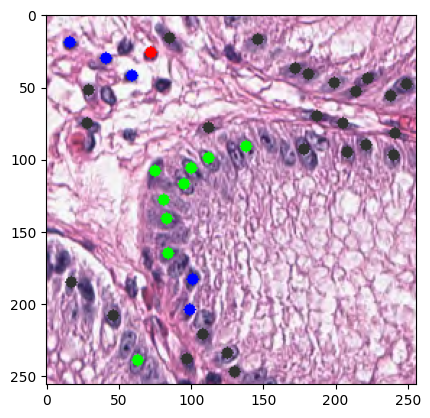

In [149]:
tile_image = cv2.imread(training_tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

for row in tile_data:
    x, y, cls = row[0], row[1], row[2]
    color = class_colors[cls]
    cv2.circle(tile_image, (x,y), radius=4, color=color, thickness=-1)
    plt.imshow(tile_image)

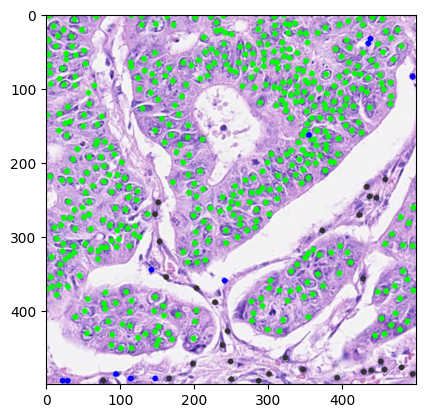

In [50]:
gt_path="/rsrch5/home/trans_mol_path/cercan/data/acformer/publicDatasets/Lizard/Train/Labels/consep_1.mat"
true_info = sio.loadmat(gt_path)
tile_true_data = np.hstack((true_info["inst_centroid"], true_info["inst_type"]))

tile_path = "/rsrch5/home/trans_mol_path/cercan/data/acformer/publicDatasets/Lizard/Train/Images/consep_1.png"
tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

for row in tile_true_data:
    x, y, cls = row[0], row[1], row[2]
    color = class_colors[cls]
    cv2.circle(tile_image, (x,y), radius=4, color=color, thickness=-1)
    plt.imshow(tile_image)

/App/ACFormer/thirdparty/mmdetection/mmdet/datasets/utils.py:66: UserWarning: "ImageToTensor" pipeline is replaced by "DefaultFormatBundle" for batch inference. It is recommended to manually replace it in the test data pipeline in your config file.
  warnings.warn(
/App/ACFormer/thirdparty/mmdetection/mmdet/models/utils/transformer.py:942: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  dim_t = temperature ** (2 * (dim_t // 2) / num_pos_feats)
/App/ACFormer/thirdparty/mmdetection/mmdet/models/dense_heads/detr_head_celldet.py:601: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (li

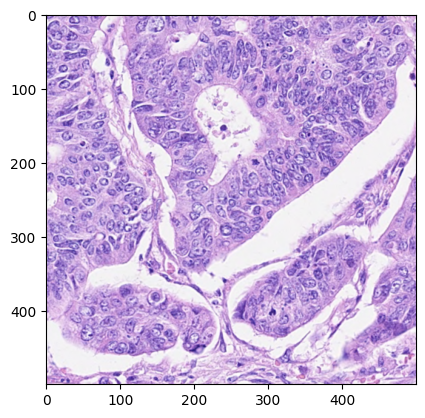

In [132]:
tile_image_pred = inference_detector(model, tile_path)
pred_centroid = []
pred_inst_type = []

for i in range(num_classes):
    tile_image = cv2.imread(tile_path)
    tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)
    classes = tile_image_pred[i][np.where(tile_image_pred[i][:, 2] > thr)]
    classes = classes[:, :2]
    pred_centroid.extend(classes)
    pred_type = np.full((classes.shape[0], 1), i + 1)
    pred_inst_type.extend(pred_type)

tile_data_pred = np.hstack((pred_centroid, pred_inst_type))
tile_data_pred = tile_data_pred.astype(int)


tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)
# for detection in tile_data_pred:
#     x, y, class_id = detection
#     if class_id != 1:
#         color = class_colors[class_id]
#         cv2.circle(tile_image, (x, y), radius=5, color=color, thickness=-1)
plt.imshow(tile_image)

In [134]:
tile_data_pred

array([[ 30, 324,   2],
       [295,  30,   2],
       [207,  85,   2],
       [416,  99,   2],
       [206, 317,   2],
       [310,  20,   2],
       [ 35, 311,   2],
       [ 78, 392,   2],
       [276,  44,   2],
       [165,  74,   2],
       [ 15,  41,   2],
       [ 38, 195,   2],
       [  6, 325,   2],
       [349, 186,   2],
       [301,  40,   2],
       [ 92, 446,   2],
       [455, 100,   2],
       [156,  65,   2],
       [ 21, 336,   2],
       [ 37,  55,   2],
       [312, 214,   2],
       [242,  57,   2],
       [276,  84,   2],
       [147,  50,   2],
       [224,  66,   2],
       [204, 244,   2],
       [ 67, 206,   2],
       [381, 164,   2],
       [347, 209,   2],
       [ 60, 315,   2],
       [115, 418,   2],
       [198, 434,   2],
       [216,  50,   2],
       [ 16, 302,   2],
       [ 27, 211,   2],
       [ 56, 428,   2],
       [375,  17,   2],
       [ 55, 239,   2],
       [277, 241,   2],
       [421,  70,   2],
       [123, 247,   2],
       [309,  64

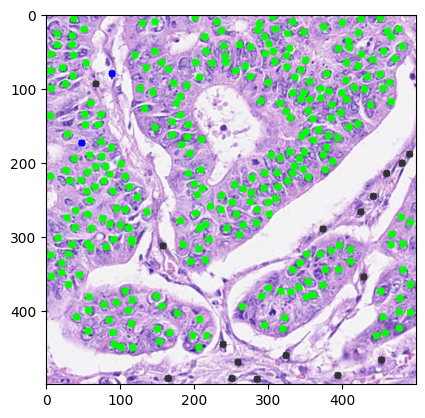

In [140]:
df = pd.DataFrame(tile_data_pred, columns=['x', 'y', 'class'])

tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

        
# Overlay each detection
for _, row in df.iterrows():
    color = class_colors[row['class']]
    x, y = int(row['x']), int(row['y'])
    tile_image = cv2.circle(tile_image, (x, y), radius=5, color=color, thickness=-1)
plt.imshow(tile_image)


In [118]:
for class_id, color in class_colors.items():
    class_detections = df[df['class'] == class_id]
    print(len(class_detections))


49
0
1
0
947
3


In [92]:
tile_data_pred

array([[ 31,   8,   1],
       [ 54,   8,   1],
       [ 56,   8,   1],
       ...,
       [351, 341,   6],
       [306, 217,   6],
       [369, 279,   6]])

In [89]:
tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)
for row in tile_data_pred:
    x, y, cls = row[0], row[1], row[2]
    if cls != 4:
    color = class_colors[cls]
    cv2.circle(tile_image, (x,y), radius=4, color=color, thickness=-1)
    plt.imshow(tile_image)

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
3
6
6
6


In [87]:
for i in range(7):
    print(i)
    print(len(tile_data_pred[np.where(tile_data_pred[:, 2] == i )]))

0
0
1
49
2
0
3
1
4
0
5
0
6
3


In [82]:
for i in range(num_classes):

    print(str(i) + ' ' +str(len(tile_image_pred[i])))

0 49
1 0
2 1
3 0
4 947
5 3
